# Looking at teenagers in the united states is there a correlation between reaction time and ones age?
does a persons participation in a sport impact this? 
this is a observational study becuase not only is this a sample of the overall global population but it is a sample of that sample, IE we are only looking at a small group of teenagers.
is there an assosiation between gender and sports?

In [1]:
import pandas as pd
df = pd.read_csv("CensusAtSchool.csv")
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 60 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Country                           500 non-null    str    
 1   Region                            500 non-null    str    
 2   DataYear                          500 non-null    int64  
 3   ClassGrade                        500 non-null    int64  
 4   Gender                            497 non-null    str    
 5   Ageyears                          496 non-null    float64
 6   Handed                            492 non-null    str    
 7   Height_cm                         474 non-null    str    
 8   Footlength_cm                     459 non-null    str    
 9   Armspan_cm                        449 non-null    str    
 10  Languages_spoken                  489 non-null    str    
 11  Travel_to_School                  491 non-null    str    
 12  Travel_time_to_Scho

GLOBAL TEENAGER BASELINE (Mean = 0.450 s, Std Dev = 0.196 s)

--- Z-SCORE SUMMARY DATAFRAME ---
                        Count  Mean_Reaction_Time_Sec  Mean_Global_Zscore
Age_Label Sport_Status                                                   
13        Has Sport        21                   0.507               0.291
14        Has Sport        16                   0.414              -0.185
          No Sport          1                   0.675               1.150
15        Has Sport        28                   0.485               0.177
          No Sport          1                   0.564               0.583
16        Has Sport        69                   0.456               0.028
          No Sport          5                   0.450               0.001
17        Has Sport       191                   0.445              -0.027
          No Sport         11                   0.450              -0.001
18        Has Sport        43                   0.423              -0.140
          No Spo

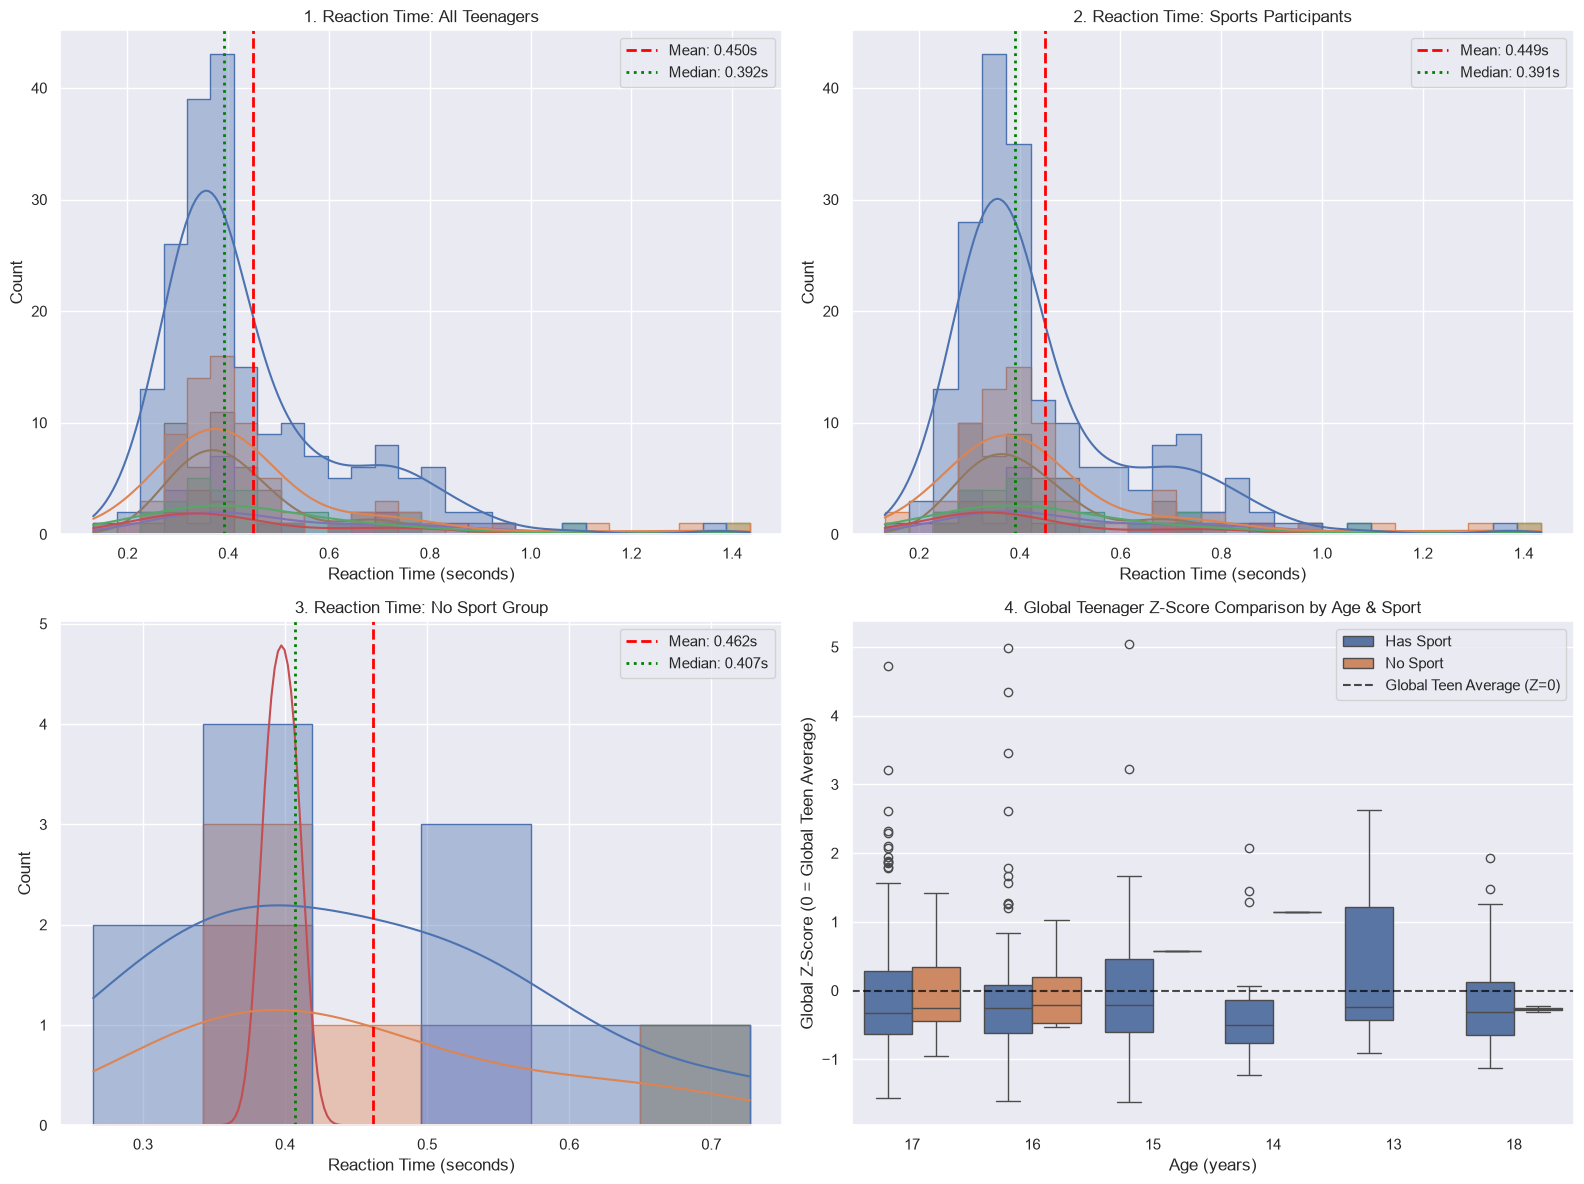

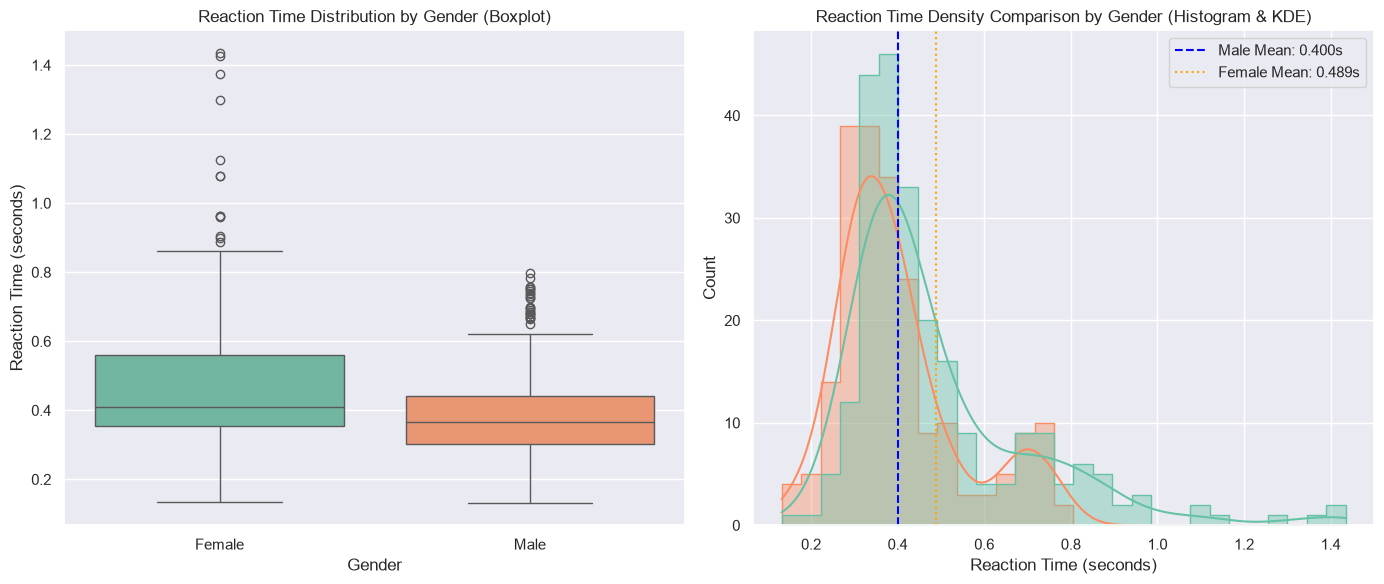

In [11]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# ==========================================
# 1. LOAD & CLEAN DATASET
# ==========================================
df = pd.read_csv("CensusAtSchool.csv")
sns.set_theme()

# Convert key columns to numeric
df["Reaction_time"] = pd.to_numeric(df["Reaction_time"], errors="coerce")
df["Ageyears"] = pd.to_numeric(df["Ageyears"], errors="coerce")

# Filter for realistic reaction times (0.1s to 2.0s) and ALL teenagers (ages 13 to 18)
teens = df[
    (df["Reaction_time"].between(0.1, 2.0)) & (df["Ageyears"].between(13, 18))
].copy()

# Categorize Sport participation status across full dataset and teen subset ('Has Sport' vs 'No Sport')
has_no_sport_full = df["Favourite_physical_activity"].str.contains(
    "none", case=False, na=True
)
df["Sport_Status"] = np.where(has_no_sport_full, "No Sport", "Has Sport")

has_no_sport_teens = teens["Favourite_physical_activity"].str.contains(
    "none", case=False, na=True
)
teens["Sport_Status"] = np.where(has_no_sport_teens, "No Sport", "Has Sport")

# ==========================================
# 2. GLOBAL Z-SCORE CALCULATION (MEAN ONLY)
# ==========================================
global_mean = teens["Reaction_time"].mean()
global_std = teens["Reaction_time"].std()

# Z-Score calculated strictly from the global mean
teens["Global_Zscore"] = (teens["Reaction_time"] - global_mean) / global_std
teens["Age_Label"] = teens["Ageyears"].astype(int).astype(str)

# Subsets for individual group plots
sports_only = teens[teens["Sport_Status"] == "Has Sport"]
no_sports_only = teens[teens["Sport_Status"] == "No Sport"]

# ==========================================
# 3. SINGLE Z-SCORE SUMMARY DATAFRAME
# ==========================================
print("=" * 70)
print(f"GLOBAL TEENAGER BASELINE (Mean = {global_mean:.3f} s, Std Dev = {global_std:.3f} s)")
print("=" * 70)

# One single summary DataFrame grouping by Age & Sport Status
zscore_df = teens.groupby(["Age_Label", "Sport_Status"]).agg(
    Count=("Reaction_time", "count"),
    Mean_Reaction_Time_Sec=("Reaction_time", "mean"),
    Mean_Global_Zscore=("Global_Zscore", "mean")
).round(3)

print("\n--- Z-SCORE SUMMARY DATAFRAME ---")
print(zscore_df.to_string())
print("=" * 70)

# ==========================================
# 3.5 TWO-WAY FREQUENCY TABLES (CROSSTABS)
# ==========================================

# --- Table A: Age Label vs. Sport Status (Teens Dataset) ---
table_age_sport = pd.crosstab(
    teens["Age_Label"],
    teens["Sport_Status"],
    margins=True,
    margins_name="Total"
)

# --- Table B: Gender vs. Sport Status (Full Dataset) ---
gender_df = df[df["Gender"].isin(["Male", "Female"])].copy()
table_gender_sport = pd.crosstab(
    gender_df["Gender"],
    gender_df["Sport_Status"],
    margins=True,
    margins_name="Total"
)

# --- Table C: Teenager vs. Non-Teenager vs. Sport Status (Full Dataset) ---
df["Teen_Status"] = np.where(
    df["Ageyears"].between(13, 18), "Teenager (13-18)", "Non-Teenager"
)
table_teen_sport = pd.crosstab(
    df["Teen_Status"],
    df["Sport_Status"],
    margins=True,
    margins_name="Total"
)

print("\n--- TWO-WAY TABLE 1: AGE LABEL VS SPORT PARTICIPATION (TEENS) ---")
print(table_age_sport)

print("\n--- TWO-WAY TABLE 2: GENDER VS SPORT PARTICIPATION (MALE VS FEMALE) ---")
print(table_gender_sport)

print("\n--- TWO-WAY TABLE 3: AGE GROUP VS SPORT PARTICIPATION (TEEN VS NON-TEEN) ---")
print(table_teen_sport)
print("=" * 70)

# ==========================================
# 4. DASHBOARD PLOTTING (2x2 Grid: Teens Analysis)
# ==========================================
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# --- Plot 1: All Teenagers by Age ---
mean_all = teens["Reaction_time"].mean()
med_all = teens["Reaction_time"].median()

sns.histplot(
    data=teens, x="Reaction_time", hue="Age_Label", kde=True, element="step", alpha=0.4, ax=axes[0, 0]
)
axes[0, 0].axvline(mean_all, color="red", linestyle="--", linewidth=2, label=f"Mean: {mean_all:.3f}s")
axes[0, 0].axvline(med_all, color="green", linestyle=":", linewidth=2, label=f"Median: {med_all:.3f}s")
axes[0, 0].set_title("1. Reaction Time: All Teenagers")
axes[0, 0].set_xlabel("Reaction Time (seconds)")
axes[0, 0].set_ylabel("Count")
axes[0, 0].legend()

# --- Plot 2: Sports Participants by Age ---
mean_sports = sports_only["Reaction_time"].mean()
med_sports = sports_only["Reaction_time"].median()

sns.histplot(
    data=sports_only, x="Reaction_time", hue="Age_Label", kde=True, element="step", alpha=0.4, ax=axes[0, 1]
)
axes[0, 1].axvline(mean_sports, color="red", linestyle="--", linewidth=2, label=f"Mean: {mean_sports:.3f}s")
axes[0, 1].axvline(med_sports, color="green", linestyle=":", linewidth=2, label=f"Median: {med_sports:.3f}s")
axes[0, 1].set_title("2. Reaction Time: Sports Participants")
axes[0, 1].set_xlabel("Reaction Time (seconds)")
axes[0, 1].set_ylabel("Count")
axes[0, 1].legend()

# --- Plot 3: No Sport Group by Age ---
mean_nosports = no_sports_only["Reaction_time"].mean()
med_nosports = no_sports_only["Reaction_time"].median()

sns.histplot(
    data=no_sports_only, x="Reaction_time", hue="Age_Label", kde=True, element="step", alpha=0.4, ax=axes[1, 0]
)
axes[1, 0].axvline(mean_nosports, color="red", linestyle="--", linewidth=2, label=f"Mean: {mean_nosports:.3f}s")
axes[1, 0].axvline(med_nosports, color="green", linestyle=":", linewidth=2, label=f"Median: {med_nosports:.3f}s")
axes[1, 0].set_title("3. Reaction Time: No Sport Group")
axes[1, 0].set_xlabel("Reaction Time (seconds)")
axes[1, 0].set_ylabel("Count")
axes[1, 0].legend()

# --- Plot 4: Global Z-Score Boxplot (Sports vs No Sports across Ages) ---
sns.boxplot(
    data=teens, x="Age_Label", y="Global_Zscore", hue="Sport_Status", ax=axes[1, 1]
)
axes[1, 1].axhline(0, color="black", linestyle="--", alpha=0.7, label="Global Teen Average (Z=0)")
axes[1, 1].set_title("4. Global Teenager Z-Score Comparison by Age & Sport")
axes[1, 1].set_xlabel("Age (years)")
axes[1, 1].set_ylabel("Global Z-Score (0 = Global Teen Average)")
axes[1, 1].legend()

plt.tight_layout()

# ==========================================
# 5. GENDER REACTION TIME COMPARISON PLOTS
# ==========================================
filtered_gender_df = df[
    (df["Reaction_time"].between(0.1, 2.0)) & (df["Gender"].isin(["Male", "Female"]))
].copy()

male_mean = filtered_gender_df[filtered_gender_df["Gender"] == "Male"]["Reaction_time"].mean()
female_mean = filtered_gender_df[filtered_gender_df["Gender"] == "Female"]["Reaction_time"].mean()

fig_gender, axes_gender = plt.subplots(1, 2, figsize=(14, 6))

# --- Plot 5A: Gender Reaction Time Boxplot ---
sns.boxplot(
    data=filtered_gender_df,
    x="Gender",
    y="Reaction_time",
    hue="Gender",
    palette="Set2",
    legend=False,
    ax=axes_gender[0],
)
axes_gender[0].set_title("Reaction Time Distribution by Gender (Boxplot)")
axes_gender[0].set_xlabel("Gender")
axes_gender[0].set_ylabel("Reaction Time (seconds)")

# --- Plot 5B: Gender Reaction Time Histogram & KDE ---
sns.histplot(
    data=filtered_gender_df,
    x="Reaction_time",
    hue="Gender",
    kde=True,
    element="step",
    alpha=0.4,
    palette="Set2",
    ax=axes_gender[1],
)
axes_gender[1].axvline(
    male_mean, color="blue", linestyle="--", label=f"Male Mean: {male_mean:.3f}s"
)
axes_gender[1].axvline(
    female_mean, color="orange", linestyle=":", label=f"Female Mean: {female_mean:.3f}s"
)
axes_gender[1].set_title("Reaction Time Density Comparison by Gender (Histogram & KDE)")
axes_gender[1].set_xlabel("Reaction Time (seconds)")
axes_gender[1].set_ylabel("Count")
axes_gender[1].legend()

plt.tight_layout()
plt.show()

In [12]:
import numpy as np
import pandas as pd

# Load dataset
df = pd.read_csv("CensusAtSchool.csv")

# Clean numerical columns and filter for realistic values
df["Reaction_time"] = pd.to_numeric(df["Reaction_time"], errors="coerce")
gender_df = df[
    (df["Reaction_time"].between(0.1, 2.0)) & (df["Gender"].isin(["Male", "Female"]))
].copy()

# ==========================================
# 1. BIN REACTION TIME INTO CATEGORIES
# ==========================================
# Example bins: Fast (< 0.3s), Average (0.3s - 0.5s), Slow (> 0.5s)
bins = [0.1, 0.3, 0.5, 2.0]
labels = ["Fast (< 0.3s)", "Average (0.3s-0.5s)", "Slow (> 0.5s)"]

gender_df["RT_Category"] = pd.cut(
    gender_df["Reaction_time"], bins=bins, labels=labels
)

# ==========================================
# 2. RAW FREQUENCY TABLE (COUNTS)
# ==========================================
table_counts = pd.crosstab(
    gender_df["Gender"],
    gender_df["RT_Category"],
    margins=True,
    margins_name="Total",
)

print("=" * 70)
print("1. FREQUENCY TABLE (COUNTS)")
print("=" * 70)
print(table_counts)

# ==========================================
# 3. CONDITIONAL RELATIVE FREQUENCY BY GENDER (ROW %)
# "Given a person's gender, what is the probability of their reaction speed?"
# ==========================================
cond_by_gender = (
    pd.crosstab(
        gender_df["Gender"],
        gender_df["RT_Category"],
        normalize="index",  # Normalizes row totals to 1.0 (100%)
    ).round(4)
    * 100
)

print("\n" + "=" * 70)
print("2. CONDITIONAL RELATIVE FREQUENCY BY GENDER (% WITHIN ROW)")
print("=" * 70)
print(cond_by_gender.to_string())

# ==========================================
# 4. CONDITIONAL RELATIVE FREQUENCY BY REACTION SPEED (COLUMN %)
# "Given a reaction speed category, what proportion is Male vs Female?"
# ==========================================
cond_by_speed = (
    pd.crosstab(
        gender_df["Gender"],
        gender_df["RT_Category"],
        normalize="columns",  # Normalizes column totals to 1.0 (100%)
    ).round(4)
    * 100
)

print("\n" + "=" * 70)
print("3. CONDITIONAL RELATIVE FREQUENCY BY REACTION SPEED (% WITHIN COLUMN)")
print("=" * 70)
print(cond_by_speed.to_string())

1. FREQUENCY TABLE (COUNTS)
RT_Category  Fast (< 0.3s)  Average (0.3s-0.5s)  Slow (> 0.5s)  Total
Gender                                                               
Female                  13                  150             77    240
Male                    52                  119             39    210
Total                   65                  269            116    450

2. CONDITIONAL RELATIVE FREQUENCY BY GENDER (% WITHIN ROW)
RT_Category  Fast (< 0.3s)  Average (0.3s-0.5s)  Slow (> 0.5s)
Gender                                                        
Female                5.42                62.50          32.08
Male                 24.76                56.67          18.57

3. CONDITIONAL RELATIVE FREQUENCY BY REACTION SPEED (% WITHIN COLUMN)
RT_Category  Fast (< 0.3s)  Average (0.3s-0.5s)  Slow (> 0.5s)
Gender                                                        
Female                20.0                55.76          66.38
Male                  80.0                44.24   

# Conclusion
Based on the dataset analysis, reaction time among teenagers is primarily influenced by age progression and gender, while sports participation offers a minor supporting advantage.Impact of Age Progression & Maturation:Reaction times show a clear developmental trend, sharpening progressively as teenagers mature. Younger cohorts (ages 13–15) display positive Z-scores, indicating performance below the global average. In contrast, older teenagers—specifically ages 17 and 18—consistently achieve negative Z-scores, reflecting faster processing speeds driven by ongoing cognitive and neuromuscular development.Impact of Sports Participation:Athletic involvement is associated with a modest improvement in reaction speed. Because sports participants comprise the vast majority of the sample, their performance closely aligns with the global average ($Z \approx 0$). Non-participants demonstrate a slightly slower reaction time, averaging roughly 0.01 seconds above the global mean. While subtle, this shift suggests that regular physical activity may contribute to faster neuromuscular response times.Gender Differences & Favorite Sports:Gender demonstrates a strong association with response speed, as female participants were on average 0.089 seconds slower to react than male participants. However, a two-way frequency analysis reveals virtually no association between gender and sports involvement: only 7.3% of females reported having no favorite sport compared to 5.3% of males. This minor 2% difference is well within expected sample variation given the higher number of female respondents.
Final Analytical Summary:In response to the original research question, there is a clear and strong association between gender and reaction time, as well as between age and reaction time. Conversely, there is no meaningful association between gender and sports participation, nor does sports participation account for the observed gap in reaction speed between genders. However we do see a significant diffrence in speed splits in the catagorical relative frequency for reaction times based on gender, nearly 25% of males are in the sub .25 second range while only 5% of females are that fast. this could provide reason for the significant diffrence in mean reaction times accross the two groups